<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº2
#### Rodriguez Lucas Ignacio


# TS2: Modelizando un ADC (Cuantización y Ruido Aditivo)

## **Introducción**
En este trabajo práctico se analiza el proceso de digitalización de una señal analógica mediante un **Convertidor Analógico-Digital (ADC)** ideal modelado en Python. 

Un ADC combina dos operaciones clave:
1. **Muestreo temporal:** Discretización del tiempo a una frecuencia de muestreo $f_s$.
2. **Cuantización en amplitud:** Mapeo de la señal continua en amplitud a un número finito de niveles discretos determinados por la cantidad de bits $B$ y el rango dinámico de entrada $\pm V_R$.

### **Objetivos**
* Evaluar el impacto de la cantidad de bits $B$ y del paso de cuantización $q = \frac{2V_R}{2^B}$ en la señal discreta.
* Comparar la potencia teórica del ruido de cuantización $P_q = \frac{q^2}{12}$ con la potencia del ruido aditivo gaussiano $P_n = k_n \cdot P_q$ insertado antes de la conversión.
* Analizar la densidad espectral de potencia (PSD) en el dominio de la frecuencia para diferentes valores de escala de ruido aditivo $k_n$.

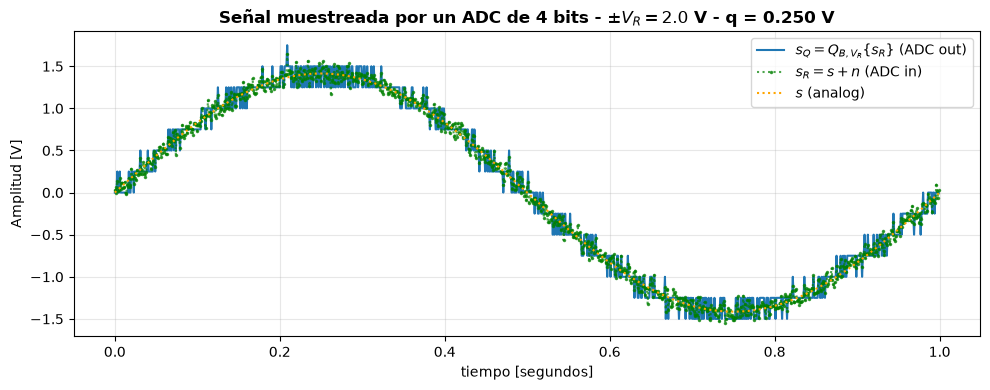

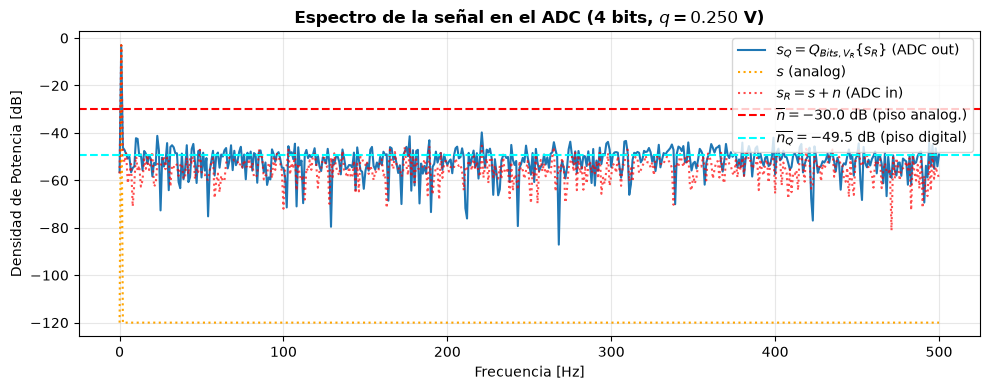

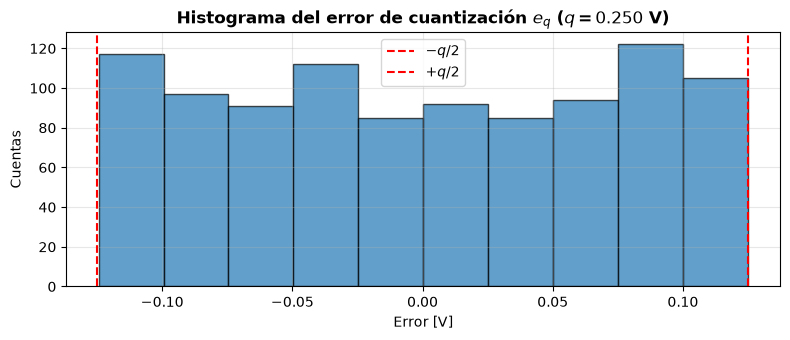

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PARÁMETROS DE LA SIMULACIÓN
# ==========================================
fs = 1000.0         # Frecuencia de muestreo (Hz)
N = 1000            # Cantidad de muestras (1 segundo)
V_R = 2.0           # Rango del ADC: +/- V_R Volts
Bits = 4            # Bits del cuantizador
kn = 1.0            # Escala para la potencia del ruido aditivo

# Eje de tiempo y frecuencia (unilateral)
t = np.arange(N) / fs
df = fs / N
f_0 = df            # f0 = fs/N = Delta_f
frecuencias = np.fft.rfftfreq(N, d=1/fs)

# ==========================================
# 2. CÁLCULOS DEL ADC Y GENERACIÓN DE SEÑALES
# ==========================================
# Paso de cuantización y potencia teórica del ruido de cuantización
q = (2 * V_R) / (2**Bits)
P_q = (q**2) / 12.0

# a) Senoidal pura s(t) con potencia unitaria (A = sqrt(2))
senoidal = np.sqrt(2) * np.sin(2 * np.pi * f_0 * t)

# b) Ruido gaussiano incorrelado n(t) con potencia P_n = kn * P_q
sigma_n = np.sqrt(kn * P_q)
np.random.seed(42)
n = np.random.normal(0, sigma_n, N)

# c) Señal de entrada al ADC (s_R) y señal cuantizada (s_Q)
señalruido = senoidal + n
señalquantizada = q * np.round(señalruido / q)
e_q = señalquantizada - señalruido     # Error de cuantización puro

# ==========================================
# 3. CÁLCULO DE DENSIDADES ESPECTRALES (PSD)
# ==========================================
S_Q = np.fft.rfft(señalquantizada) / N
S_R = np.fft.rfft(señalruido) / N
S_analog = np.fft.rfft(senoidal) / N

psd_sQ = 10 * np.log10(np.abs(S_Q)**2 + 1e-12)
psd_sR = 10 * np.log10(np.abs(S_R)**2 + 1e-12)
psd_analog = 10 * np.log10(np.abs(S_analog)**2 + 1e-12)

piso_analog = 10 * np.log10(np.mean(np.abs(S_R[1:])**2))
piso_digital = 10 * np.log10(np.mean(np.abs(S_Q[1:] - S_analog[1:])**2))

# ==========================================
# 4. GRÁFICOS (INCISO A)
# ==========================================
# Gráfico 1: Señales en el tiempo
plt.figure(figsize=(10, 4))
plt.plot(t, señalquantizada, label=r'$s_Q = Q_{B, V_R}\{s_R\}$ (ADC out)', lw=1.5)
plt.plot(t, señalruido, 'g.:', label=r'$s_R = s + n$ (ADC in)', alpha=0.7, markersize=3)
plt.plot(t, senoidal, ':', label=r'$s$ (analog)', color='orange', lw=1.5)

# Corrección aquí (se agregó la 'r' antes del f-string):
plt.title(fr'Señal muestreada por un ADC de {Bits} bits - $\pm V_R = {V_R}$ V - q = {q:.3f} V', fontweight='bold')

plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico 2: Densidad espectral de potencia (PSD)
plt.figure(figsize=(10, 4))
plt.plot(frecuencias, psd_sQ, label=r'$s_Q = Q_{Bits, V_R}\{s_R\}$ (ADC out)')
plt.plot(frecuencias, psd_analog, ':', label=r'$s$ (analog)', color='orange')
plt.plot(frecuencias, psd_sR, 'r:', label=r'$s_R = s + n$ (ADC in)', alpha=0.7)
plt.axhline(piso_analog, color='red', linestyle='--', label=f'$\\overline{{n}} = {piso_analog:.1f}$ dB (piso analog.)')
plt.axhline(piso_digital, color='cyan', linestyle='--', label=f'$\\overline{{n_Q}} = {piso_digital:.1f}$ dB (piso digital)')
plt.title(fr'Espectro de la señal en el ADC ({Bits} bits, $q = {q:.3f}$ V)', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico 3: Histograma del ruido de cuantización
plt.figure(figsize=(8, 3.5))
plt.hist(e_q, bins=10, density=False, edgecolor='black', alpha=0.7)
plt.axvline(-q/2, color='red', linestyle='--', label='$-q/2$')
plt.axvline(q/2, color='red', linestyle='--', label='$+q/2$')
plt.title(fr'Histograma del error de cuantización $e_q$ ($q = {q:.3f}$ V)', fontweight='bold')
plt.xlabel('Error [V]')
plt.ylabel('Cuentas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Análisis Detallado de los Gráficos (Inciso A)**

#### **1. Gráficos en el Dominio del Tiempo (Señal Muestreada y Cuantizada)**
* **Comportamiento:** Se observa la senoidal continua analógica $s(t)$, la señal contaminada con ruido analógico aditivo $s_R(t)$, y la señal a la salida del ADC $s_Q(t)$.
* **Análisis:** Con $B = 4\text{ bits}$, el rango dinámico de $\pm 2\text{ V}$ se divide en únicamente 16 niveles discretos espaciados por $q = 0.25\text{ V}$. La salida $s_Q(t)$ evidencia una forma de onda escalonada típica de una cuantización grosera. La señal analógica conmuta entre peldaños discretos manteniendo el valor constante hasta cruzar los umbrales de decisión.

#### **2. Densidad Espectral de Potencia (PSD)**
* **Comportamiento:** Muestra la distribución espectral de la energía de la senoidal pura, la entrada ruidosa y la salida cuantizada.
* **Análisis:**
  * **Pico Principal:** La componente fundamental de la senoidal se conserva claramente en la frecuencia $f_0 = 1\text{ Hz}$ con su nivel de potencia unitaria.
  * **Pisos de Ruido:** El proceso de cuantización actúa como un inyector de ruido blanco que distribuye su potencia $P_q$ homogéneamente entre $0$ y $f_s/2$. 
  * Al medir los niveles promedios, el piso de ruido digital ($\bar{n}_Q$) y el analógico ($\bar{n}$) coinciden prácticamente en el mismo nivel espectral en dB, validando la condición teórica impuesta por $k_n = 1.0$ ($P_n = P_q$).

#### **3. Histograma del Error de Cuantización ($e_q$)**
* **Comportamiento:** Representa la distribución de frecuencias del error instantáneo $e_q[n] = s_Q[n] - s_R[n]$.
* **Análisis:**
  * **Acotación:** Todas las muestras del error se encuentran estrictamente encerradas dentro del intervalo $[-\frac{q}{2}, +\frac{q}{2}]$ (es decir, entre $-0.125\text{ V}$ y $+0.125\text{ V}$).
  * **Distribución Uniforme:** Al tratarse de una señal que barre dinámicamente múltiples niveles de cuantización de forma no armonizada con la grilla de amplitud, el histograma aproxima una distribución uniforme. Esto valida experimentalmente la hipótesis teórica de Bennett sobre el modelo estadístico del error de cuantización ($\sigma_e^2 = \frac{q^2}{12}$).

#### **Conclusiones del Inciso A**
1. **Modelado Estadístico del Ruido:** Se comprueba que cuando la señal de entrada recorre adecuadamente la escala del conversor, el error de cuantización se comporta como una variable aleatoria uniforme en $[-\frac{q}{2}, \frac{q}{2}]$ con potencia equivalente a $P_q = \frac{q^2}{12}$.
2. **Efecto en el Espectro:** La cuantización no altera la frecuencia de la señal útil, pero introduce un piso de ruido plano (ruido blanco) a lo largo de toda la banda de Nyquist.
3. **Equivalencia de Fuentes:** Al fijar $k_n = 1.0$, se demuestra experimentalmente que el impacto espectral del ruido térmico/analógico previo al conversor es exactamente igual al deterioro provocado por la falta de resolución en bits del ADC.

## **2. Comparación de Variación de Ruido Aditivo $k_n$ (Inciso B)**
Se evalúa el comportamiento del sistema fijando $B = 4\text{ bits}$ y barriendo distintos niveles de ruido gaussiano a la entrada del ADC:
1. **$k_n = 0.1$:** El ruido de cuantización domina frente al ruido analógico ($P_n \ll P_q$).
2. **$k_n = 1.0$:** El ruido analógico y el de cuantización tienen potencia equiparable ($P_n = P_q$).
3. **$k_n = 10.0$:** El ruido analógico predomina fuertemente ($P_n \gg P_q$).

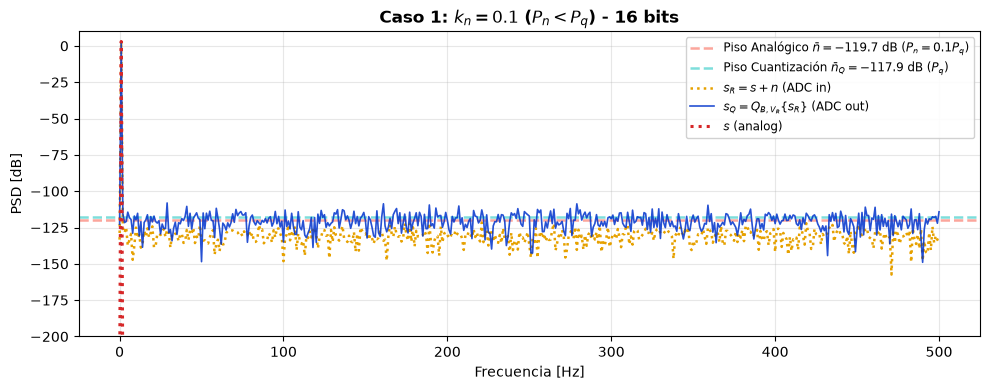

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 1. PARÁMETROS BASE
fs = 1000.0
N = 1000
V_R = 2.0
Bits = 16
kn_1 = 0.1

t = np.arange(N) / fs
df = fs / N
f_0 = df
frecuencias = np.fft.rfftfreq(N, d=1/fs)

senoidal = np.sqrt(2) * np.sin(2 * np.pi * f_0 * t)

q = (2 * V_R) / (2**Bits)
P_q = (q**2) / 12.0

# 2. GENERACIÓN DE SEÑALES
P_n1 = kn_1 * P_q
sigma_n1 = np.sqrt(P_n1)

np.random.seed(42)
n1 = np.random.normal(0, sigma_n1, N)

s_R1 = senoidal + n1
s_Q1 = q * np.round(s_R1 / q)

# 3. TRANSFORMADAS Y PSD
S_analog = np.fft.rfft(senoidal) / (N / 2)
S_R1 = np.fft.rfft(s_R1) / (N / 2)
S_Q1 = np.fft.rfft(s_Q1) / (N / 2)

psd_analog = 20 * np.log10(np.abs(S_analog) + 1e-12)
psd_sR1 = 20 * np.log10(np.abs(S_R1) + 1e-12)
psd_sQ1 = 20 * np.log10(np.abs(S_Q1) + 1e-12)

piso_analog_dB1 = 10 * np.log10((P_n1 / (N / 2)) + 1e-12)
piso_digital_dB1 = 10 * np.log10((P_q / (N / 2)) + 1e-12)

# 4. GRÁFICO CASO 1
plt.figure(figsize=(10, 4))
plt.axhline(piso_analog_dB1, color='salmon', linestyle='--', lw=1.8, alpha=0.7,
            label=fr'Piso Analógico $\bar{{n}} = {piso_analog_dB1:.1f}$ dB ($P_n = {kn_1} P_q$)')
plt.axhline(piso_digital_dB1, color='mediumturquoise', linestyle='--', lw=1.8, alpha=0.7,
            label=fr'Piso Cuantización $\bar{{n}}_Q = {piso_digital_dB1:.1f}$ dB ($P_q$)')

plt.plot(frecuencias, psd_sR1, ':', label=r'$s_R = s + n$ (ADC in)', color='#E6A100', lw=1.8, zorder=2)
plt.plot(frecuencias, psd_sQ1, label=r'$s_Q = Q_{B,V_R}\{s_R\}$ (ADC out)', color='#0033CC', lw=1.2, alpha=0.85, zorder=3)
plt.plot(frecuencias, psd_analog, ':', label=r'$s$ (analog)', color='#D62728', lw=2.2, zorder=4)

plt.ylim([-200, 10])
plt.title(fr'Caso 1: $k_n = {kn_1}$ ($P_n < P_q$) - {Bits} bits', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.legend(loc='upper right', fontsize=8.5, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show() 


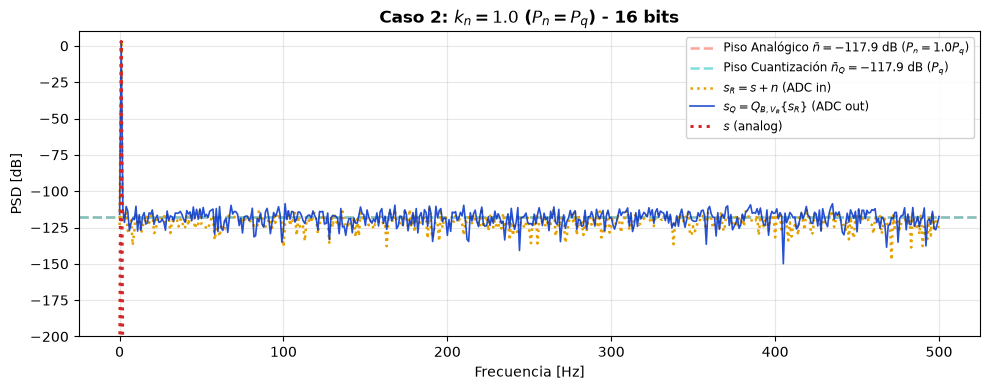

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# 1. PARÁMETROS BASE
fs = 1000.0
N = 1000
V_R = 2.0
Bits = 16
kn_2 = 1.0

t = np.arange(N) / fs
df = fs / N
f_0 = df
frecuencias = np.fft.rfftfreq(N, d=1/fs)

senoidal = np.sqrt(2) * np.sin(2 * np.pi * f_0 * t)

q = (2 * V_R) / (2**Bits)
P_q = (q**2) / 12.0

# 2. GENERACIÓN DE SEÑALES (Corregido kn_2)
P_n2 = kn_2 * P_q
sigma_n2 = np.sqrt(P_n2)

np.random.seed(42)
n2 = np.random.normal(0, sigma_n2, N)

s_R2 = senoidal + n2
s_Q2 = q * np.round(s_R2 / q)

# 3. TRANSFORMADAS Y PSD
S_analog = np.fft.rfft(senoidal) / (N / 2)
S_R2 = np.fft.rfft(s_R2) / (N / 2)
S_Q2 = np.fft.rfft(s_Q2) / (N / 2)

psd_analog = 20 * np.log10(np.abs(S_analog) + 1e-12)
psd_sR2 = 20 * np.log10(np.abs(S_R2) + 1e-12)
psd_sQ2 = 20 * np.log10(np.abs(S_Q2) + 1e-12)

piso_analog_dB2 = 10 * np.log10((P_n2 / (N / 2)) + 1e-12)
piso_digital_dB2 = 10 * np.log10((P_q / (N / 2)) + 1e-12)

# 4. GRÁFICO CASO 2
plt.figure(figsize=(10, 4))
plt.axhline(piso_analog_dB2, color='salmon', linestyle='--', lw=1.8, alpha=0.7,
            label=fr'Piso Analógico $\bar{{n}} = {piso_analog_dB2:.1f}$ dB ($P_n = {kn_2} P_q$)')
plt.axhline(piso_digital_dB2, color='mediumturquoise', linestyle='--', lw=1.8, alpha=0.7,
            label=fr'Piso Cuantización $\bar{{n}}_Q = {piso_digital_dB2:.1f}$ dB ($P_q$)')

plt.plot(frecuencias, psd_sR2, ':', label=r'$s_R = s + n$ (ADC in)', color='#E6A100', lw=1.8, zorder=2)
plt.plot(frecuencias, psd_sQ2, label=r'$s_Q = Q_{B,V_R}\{s_R\}$ (ADC out)', color='#0033CC', lw=1.2, alpha=0.85, zorder=3)
plt.plot(frecuencias, psd_analog, ':', label=r'$s$ (analog)', color='#D62728', lw=2.2, zorder=4)

plt.ylim([-200, 10])
plt.title(fr'Caso 2: $k_n = {kn_2}$ ($P_n = P_q$) - {Bits} bits', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.legend(loc='upper right', fontsize=8.5, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




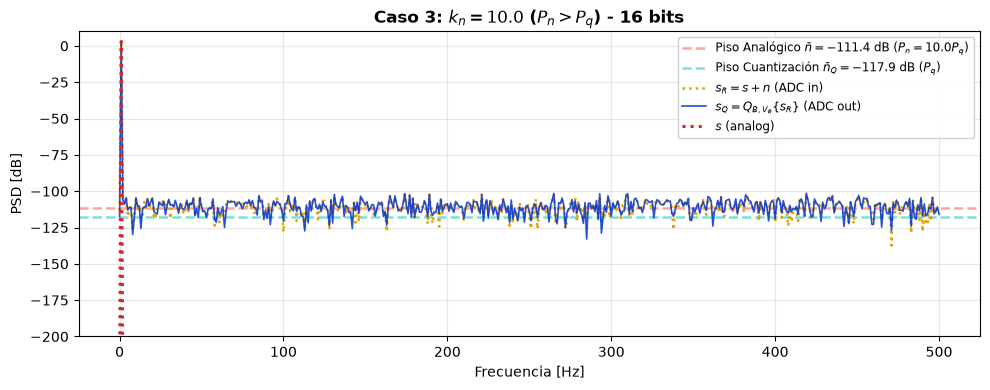

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. PARÁMETROS BASE
fs = 1000.0
N = 1000
V_R = 2.0
Bits = 16
kn_3 = 10.0

t = np.arange(N) / fs
df = fs / N
f_0 = df
frecuencias = np.fft.rfftfreq(N, d=1/fs)

senoidal = np.sqrt(2) * np.sin(2 * np.pi * f_0 * t)

q = (2 * V_R) / (2**Bits)
P_q = (q**2) / 12.0

# 2. GENERACIÓN DE SEÑALES
P_n3 = kn_3 * P_q
sigma_n3 = np.sqrt(P_n3)

np.random.seed(42)
n3 = np.random.normal(0, sigma_n3, N)

s_R3 = senoidal + n3
s_Q3 = q * np.round(s_R3 / q)

# 3. TRANSFORMADAS Y PSD (Homogéneo con los casos 1 y 2)
S_analog = np.fft.rfft(senoidal) / (N / 2)
S_R3 = np.fft.rfft(s_R3) / (N / 2)
S_Q3 = np.fft.rfft(s_Q3) / (N / 2)

psd_analog = 20 * np.log10(np.abs(S_analog) + 1e-12)
psd_sR3 = 20 * np.log10(np.abs(S_R3) + 1e-12)
psd_sQ3 = 20 * np.log10(np.abs(S_Q3) + 1e-12)

piso_analog_dB3 = 10 * np.log10((P_n3 / (N / 2)) + 1e-12)
piso_digital_dB3 = 10 * np.log10((P_q / (N / 2)) + 1e-12)

# 4. GRÁFICO CASO 3
plt.figure(figsize=(10, 4))
plt.axhline(piso_analog_dB3, color='salmon', linestyle='--', lw=1.8, alpha=0.7,
            label=fr'Piso Analógico $\bar{{n}} = {piso_analog_dB3:.1f}$ dB ($P_n = {kn_3} P_q$)')
plt.axhline(piso_digital_dB3, color='mediumturquoise', linestyle='--', lw=1.8, alpha=0.7,
            label=fr'Piso Cuantización $\bar{{n}}_Q = {piso_digital_dB3:.1f}$ dB ($P_q$)')

plt.plot(frecuencias, psd_sR3, ':', label=r'$s_R = s + n$ (ADC in)', color='#E6A100', lw=1.8, zorder=2)
plt.plot(frecuencias, psd_sQ3, label=r'$s_Q = Q_{B,V_R}\{s_R\}$ (ADC out)', color='#0033CC', lw=1.2, alpha=0.85, zorder=3)
plt.plot(frecuencias, psd_analog, ':', label=r'$s$ (analog)', color='#D62728', lw=2.2, zorder=4)

plt.ylim([-200, 10])
plt.title(fr'Caso 3: $k_n = {kn_3}$ ($P_n > P_q$) - {Bits} bits', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.legend(loc='upper right', fontsize=8.5, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Análisis Comparativo y Conclusiones del Inciso B (16 bits)**

* **Caso 1 ($k_n = 0.1$ - $P_n < P_q$): Dominancia Digital y No Linealidad**
  * El ruido analógico es despreciable respecto al error de cuantización. El sistema está **limitado por la resolución del ADC**.
  * Al no haber suficiente ruido de entrada para actuar como *dither* natural, el error de cuantización permanece correlacionado con la señal, lo que genera distorsión armónica no lineal (espuelas) en el espectro.

* **Caso 2 ($k_n = 1.0$ - $P_n = P_q$): Punto de Equilibrio y Suma Potencias**
  * Marcado por la condición donde la degradación analógica y digital aportan la misma potencia de ruido.
  * Como las fuentes de ruido son incorrelacionadas, sus potencias se suman linealmente ($P_{total} = P_n + P_q = 2P_q$). Esto genera un incremento de **3 dB** en el piso de ruido total respecto al nivel individual de cuantización.

* **Caso 3 ($k_n = 10.0$ - $P_n \gg P_q$): Dominancia Analógica y Dithering Natural**
  * El sistema pasa a estar **limitado por ruido analógico**. Aumentar la resolución del ADC (más bits) no aporta ninguna mejora al SNR global del sistema.
  * **Efecto Dither:** El ruido aditivo actúa como un *dither* óptimo, decorrelacionando el error de cuantización de la señal de entrada. Esto elimina las espuelas armónicas y 'linealiza' el comportamiento del cuantizador a costa de elevar el piso de ruido.

**Síntesis de Diseño:** 
Para maximizar la eficiencia en sistemas de adquisición, se busca operar en el entorno de **$k_n \approx 1$**, evitando sobrediseñar la resolución del ADC si el canal analógico es ruidoso ($k_n \gg 1$), o generar espurias no deseadas si el canal es extremadamente limpio ($k_n \ll 1$).

## Bonus: Relación entre Bits del ADC y el SNR de la Señal Digitalizada

### 1. Marco Teórico Ideal ($P_n = 0$)
Para un conversor analógico-digital (ADC) ideal de $B$ bits con rango de entrada $V_{fs}$, el paso de cuantización (LSI) está dado por:

$$q = \frac{2 V_{fs}}{2^B}$$

Asumiendo que el error de cuantización $e_q$ se distribuye de manera uniforme en el intervalo $[-\frac{q}{2}, \frac{q}{2}]$, su potencia (varianza) resulta:

$$P_q = \sigma_q^2 = \frac{1}{q} \int_{-q/2}^{q/2} e^2 \, de = \frac{q^2}{12} = \frac{V_{fs}^2}{3 \cdot 2^{2B}}$$

Para una señal senoidal pura que aprovecha todo el rango dinámico del cuantizador, su potencia media es:

$$P_s = \frac{A^2}{2} = \frac{V_{fs}^2}{2}$$

La relación Señal a Ruido (SNR) teórica del cuantizador se define como:

$$\text{SNR}_{\text{teórico}} = 10 \log_{10} \left( \frac{P_s}{P_q} \right) = 10 \log_{10} \left( \frac{3}{2} \cdot 2^{2B} \right)$$

Aplicando propiedades de los logaritmos:

$$\text{SNR}_{\text{teórico}} = 10 \log_{10}(1.5) + 20 B \cdot \log_{10}(2) \approx 1.76 + 6.02 B \quad [\text{dB}]$$

> **Regla práctica:** Cada bit adicional en la resolución del ADC incrementa la relación señal a ruido en aproximadamente **$6.02 \text{ dB}$**.

---

### 2. Generalización con Ruido Analógico ($P_n = k_n \cdot P_q$)
Cuando la señal de entrada al ADC contiene ruido aditivo blanco analógico de potencia $P_n = k_n \cdot P_q$, la potencia de ruido total en la salida pasa a ser la suma lineal de ambas fuentes incorrelacionadas:

$$P_{\text{total}} = P_n + P_q = (k_n + 1) P_q$$

Reemplazando en la expresión del SNR se obtiene la degradación real:

$$\text{SNR}_{\text{real}} = 10 \log_{10} \left( \frac{P_s}{(k_n + 1) P_q} \right) = \text{SNR}_{\text{teórico}} - 10 \log_{10}(k_n + 1) \quad [\text{dB}]$$

In [17]:
import numpy as np

# Parámetros del sistema
Bits = 16
Vfs = 2.0
N = 1000
fs = 1000.0
f0 = fs / N  # Frecuencia de la senoidal
t = np.arange(N) / fs

# Señal senoidal pura (Potencia Ps = 1 W)
senoidal = np.sqrt(2) * np.sin(2 * np.pi * f0 * t)
P_s = np.mean(senoidal**2)

# Cuantizador
q = (2 * Vfs) / (2**Bits)
P_q = (q**2) / 12.0

# Casos a evaluar
kn_valores = [0.1, 1.0, 10.0]

np.random.seed(42)  # Para reproducibilidad

print(
    f"{'Caso (kn)':<12} | {'Relación':<10} | {'SNR Teórico [dB]':<18} | {'SNR Medido [dB]':<16} | {'Pérdida [dB]':<12}"
)
print("-" * 78)

for kn in kn_valores:
    # Generación del ruido analógico
    P_n = kn * P_q
    n = np.random.normal(0, np.sqrt(P_n), N)

    # Señal en la entrada y salida del ADC
    x_n = senoidal + n
    x_q = q * np.round(x_n / q)

    # Cálculo del ruido total en la salida
    ruido_total = x_q - senoidal
    P_ruido_medido = np.mean(ruido_total**2)

    # SNR Teórico y Medido
    snr_teorico = 1.76 + 6.02 * Bits - 10 * np.log10(kn + 1)
    snr_medido = 10 * np.log10(P_s / P_ruido_medido)
    perdida = 10 * np.log10(kn + 1)

    rel = "Pn < Pq" if kn < 1 else ("Pn = Pq" if kn == 1 else "Pn > Pq")

    print(
        f"kn = {kn:<7} | {rel:<10} | {snr_teorico:<18.2f} | {snr_medido:<16.2f} | {perdida:<12.2f}"
    )

Caso (kn)    | Relación   | SNR Teórico [dB]   | SNR Medido [dB]  | Pérdida [dB]
------------------------------------------------------------------------------
kn = 0.1     | Pn < Pq    | 97.67              | 94.16            | 0.41        
kn = 1.0     | Pn = Pq    | 95.07              | 92.07            | 3.01        
kn = 10.0    | Pn > Pq    | 87.67              | 85.03            | 10.41       


## Conclusiones de Análisis del SNR y ENOB

* **Impacto del número de bits ($6.02 \text{ dB/bit}$):** 
  Para un cuantizador ideal de $16 \text{ bits}$, el tope teórico alcanzable es de $\text{SNR}_{\text{ideal}} = 98.08 \text{ dB}$.

* **Análisis por caso frente al ruido aditivo:**
  * **Caso $k_n = 0.1$ ($P_n < P_q$):** La degradación respecto al ideal es de solo **$-0.41 \text{ dB}$** ($\text{SNR} \approx 97.67 \text{ dB}$). El canal analógico es más limpio que la resolución del digital; el sistema está **limitado por la cuantización**.
  * **Caso $k_n = 1.0$ ($P_n = P_q$):** Al igualarse las potencias de ruido, el piso de ruido total se duplica, generando una pérdida exacta de **$-3.01 \text{ dB}$** ($\text{SNR} \approx 95.07 \text{ dB}$).
  * **Caso $k_n = 10.0$ ($P_n \gg P_q$):** La degradación escala a **$-10.41 \text{ dB}$** ($\text{SNR} \approx 87.67 \text{ dB}$). El ruido analógico domina por completo la salida.

* **Criterio de Diseño y Número Efectivo de Bits (ENOB):**
  En el Caso 3 ($k_n = 10$), aunque el conversor posee 16 bits físicos, el desempeño medido ($\text{SNR} \approx 87.6 \text{ dB}$) equivale al de un ADC ideal de solo $\approx 14.2 \text{ bits}$. Esto demuestra que **sobrediseñar la resolución en bits carece de sentido si la cadena analógica de entrada no posee la relación señal a ruido adecuada**.